# NumPy 项目实践：从向量化到手写两层 MLP

目标：只依赖 NumPy 完成二维数据生成、向量化、前向传播、softmax cross-entropy、反向传播、梯度检查、mini-batch 训练和决策边界可视化。Matplotlib 只负责绘图，不参与模型计算。

验收标准：能够解释每个张量和梯度的 shape；梯度检查误差足够小；验证集准确率明显高于线性基线；能观察学习率对收敛的影响。

In [1]:
# dataclass 用于把模型参数和前向缓存组织成具名结构，避免依赖位置传参。
from dataclasses import dataclass
# perf_counter 提供高精度单调时钟，用于比较循环与向量化实现的耗时。
from time import perf_counter

# Matplotlib 只负责绘图，不参与数据生成、模型计算或参数更新。
import matplotlib.pyplot as plt
# NumPy 提供本文所需的数组、随机数、矩阵运算和数值函数。
import numpy as np

# precision=4 控制浮点数显示精度；suppress=True 避免小数轻易显示为科学计数法。
np.set_printoptions(precision=4, suppress=True)
# 输出实际 NumPy 版本，保证实验结果具有环境上下文。
print("NumPy:", np.__version__)


NumPy: 1.26.4


## 1. 只用 NumPy 构造、切分并标准化数据

双月牙数据不是线性可分问题，适合验证隐藏层是否真的学到了非线性边界。标准化只能使用训练集统计量，避免验证集信息泄漏。

In [2]:
def make_moons_numpy(n_samples=1200, noise=0.22, seed=42):
    # default_rng 创建局部随机数生成器；固定 seed 让数据可以复现且不污染全局状态。
    rng = np.random.default_rng(seed)
    # 第一类取一半样本；整除可以兼容奇数样本量。
    n_first = n_samples // 2
    # 第二类接收剩余样本，保证两类数量之和严格等于 n_samples。
    n_second = n_samples - n_first

    # linspace 在 [0, π] 上生成第一段半圆的等距角度，shape 为 (n_first,)。
    first_angle = np.linspace(0.0, np.pi, n_first)
    # 第二段角度独立生成，从而兼容两类样本数不相同的情况。
    second_angle = np.linspace(0.0, np.pi, n_second)
    # np.c_ 按列拼接 cos/sin 坐标，得到第一类的 (n_first, 2) 特征矩阵。
    first = np.c_[np.cos(first_angle), np.sin(first_angle)]
    # 平移并翻转第二个半圆，形成与第一类交错的非线性双月牙。
    second = np.c_[1.0 - np.cos(second_angle), 0.5 - np.sin(second_angle)]

    # vstack 沿样本轴拼接两类特征，x 的 shape 变为 (n_samples, 2)。
    x = np.vstack([first, second])
    # 生成与 x 同 shape 的高斯噪声并原地相加，让分类任务更接近真实数据。
    x += rng.normal(0.0, noise, size=x.shape)
    # 前半标签为 0、后半标签为 1；int64 可直接作为类别索引使用。
    y = np.concatenate([np.zeros(n_first), np.ones(n_second)]).astype(np.int64)

    # permutation 生成 0 到 n_samples-1 的随机排列，打散按类别排列的数据。
    order = rng.permutation(n_samples)
    # 对 x 和 y 使用同一组索引，确保样本与标签仍一一对应。
    return x[order], y[order]


def stratified_split(x, y, val_ratio=0.25, seed=42):
    # 使用独立随机数生成器，使数据切分可以由 seed 单独复现。
    rng = np.random.default_rng(seed)
    # 用列表暂存每个类别的训练索引，最后再统一拼接。
    train_indices = []
    # 用列表暂存每个类别的验证索引，保证验证集类别比例稳定。
    val_indices = []
    # unique 返回所有类别；逐类切分就是最小实现的 stratified split。
    for label in np.unique(y):
        # flatnonzero 把布尔条件转换成当前类别的一维样本索引。
        label_indices = np.flatnonzero(y == label)
        # 原地打乱当前类别索引，避免切分受原始顺序影响。
        rng.shuffle(label_indices)
        # 按当前类别样本数计算验证集数量。
        val_count = int(label_indices.size * val_ratio)
        # 前 val_count 个索引进入验证集。
        val_indices.append(label_indices[:val_count])
        # 其余索引进入训练集。
        train_indices.append(label_indices[val_count:])

    # concatenate 将各类别训练索引合并成一个一维索引数组。
    train_indices = np.concatenate(train_indices)
    # concatenate 将各类别验证索引合并成一个一维索引数组。
    val_indices = np.concatenate(val_indices)
    # 再次打乱训练索引，避免 mini-batch 按类别成块出现。
    rng.shuffle(train_indices)
    # 验证索引也打乱，使验证输出不依赖类别排列。
    rng.shuffle(val_indices)
    # 高级索引同时切分特征和标签，并保持两者严格对齐。
    return x[train_indices], y[train_indices], x[val_indices], y[val_indices]


# 生成 1200 条二维双月牙样本；x 为特征，y 为整数标签。
x, y = make_moons_numpy()
# 以 3:1 的比例分层切分训练集和验证集。
x_train, y_train, x_val, y_val = stratified_split(x, y)
# axis=0 按列求均值；keepdims=True 保留 (1, 2)，便于显式广播。
mean = x_train.mean(axis=0, keepdims=True)
# 只用训练集计算每个特征的标准差，避免验证集信息泄漏。
std = x_train.std(axis=0, keepdims=True)
# 使用训练统计量标准化训练集，并固定为 float64 方便后续梯度检查。
x_train = ((x_train - mean) / std).astype(np.float64)
# 验证集必须复用训练集统计量，模拟面对未知数据时的预处理。
x_val = ((x_val - mean) / std).astype(np.float64)

# 打印训练特征和标签 shape，确认样本轴数量一致。
print("train:", x_train.shape, y_train.shape)
# 打印验证特征和标签 shape，确认切分结果符合预期。
print("val:  ", x_val.shape, y_val.shape)
# 标准化后训练集每个特征的均值应接近 0。
print("train mean:", x_train.mean(axis=0))
# 标准化后训练集每个特征的标准差应接近 1。
print("train std: ", x_train.std(axis=0))


train: (900, 2) (900,)
val:   (300, 2) (300,)
train mean: [ 0. -0.]
train std:  [1. 1.]


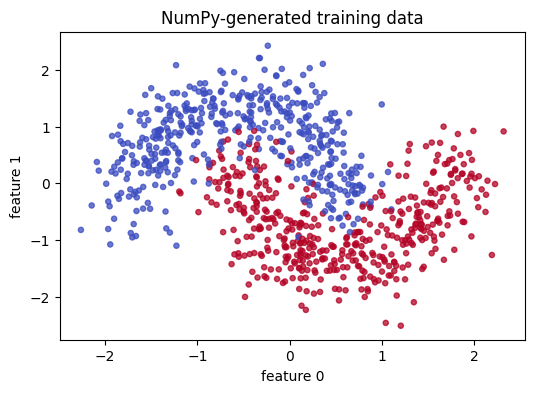

In [3]:
# 创建 6×4 英寸画布，避免使用 Matplotlib 的隐式默认画布。
plt.figure(figsize=(6, 4))
# 两列特征分别作为横纵坐标；c=y_train 用颜色编码类别。
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    s=14,
    cmap="coolwarm",
    alpha=0.75,
)
# 标题说明数据由 NumPy 生成。
plt.title("NumPy-generated training data")
# 横轴对应标准化后的第 0 个特征。
plt.xlabel("feature 0")
# 纵轴对应标准化后的第 1 个特征。
plt.ylabel("feature 1")
# 显式显示当前图像，兼容本地 Jupyter 与 JupyterLite。
plt.show()


## 2. 从 Python 循环过渡到广播与向量化

计算 N 个 128 维样本到同一个向量的欧氏距离。两种实现必须先验证数值一致，再比较耗时。耗时依赖机器和浏览器，本 Cell 只用于观察量级，不作为严格 benchmark。

In [4]:
# 固定随机种子，确保循环版与向量化版每次比较相同数据。
rng = np.random.default_rng(7)
# 生成 10000 个 128 维样本，shape 为 (10000, 128)。
points = rng.normal(size=(10000, 128))
# 生成一个 128 维查询向量，shape 为 (128,)。
query = rng.normal(size=(128,))

# 记录 Python 循环开始时间。
start = perf_counter()
# 预分配一维输出，避免 append 带来的动态扩容干扰。
loop_distance = np.empty(points.shape[0])
# Python 逐样本调度 10000 次距离计算。
for i in range(points.shape[0]):
    # 先逐元素求差与平方，再沿 128 维求和并开平方。
    loop_distance[i] = np.sqrt(np.sum((points[i] - query) ** 2))
# 结束时间减开始时间得到循环版本耗时。
loop_seconds = perf_counter() - start

# 记录向量化实现开始时间。
start = perf_counter()
# query 从 (128,) 广播到 (10000, 128)；axis=1 对每条样本的特征求和。
vector_distance = np.sqrt(np.sum((points - query) ** 2, axis=1))
# 记录整块数组计算的耗时。
vector_seconds = perf_counter() - start

# 性能比较前先验证两种实现数值一致，防止“加速”改变语义。
np.testing.assert_allclose(loop_distance, vector_distance)
# 输出循环版本耗时，保留 4 位小数。
print(f"loop:       {loop_seconds:.4f} s")
# 输出向量化版本耗时，保留 4 位小数。
print(f"vectorized: {vector_seconds:.4f} s")
# 用循环耗时除以向量化耗时，得到本次运行的相对加速比。
print(f"speedup:    {loop_seconds / vector_seconds:.1f}x")


loop:       0.1010 s
vectorized: 0.0196 s
speedup:    5.1x


## 3. 两层 MLP：forward 与稳定 softmax

网络结构为 input → linear1 → ReLU → linear2 → softmax。对于 batch size B、输入维度 D、隐藏维度 H 和类别数 C：

- X: (B, D)
- W1: (D, H)，b1: (H,)
- Z1、A1: (B, H)
- W2: (H, C)，b2: (C,)
- logits、probs: (B, C)

softmax 先按行减去最大 logits，避免指数溢出。

In [5]:
# dataclass 自动生成初始化方法，让四组参数按名称访问。
@dataclass
class MLPParams:
    # 第一层权重，shape 为 (input_dim, hidden_dim)。
    w1: np.ndarray
    # 第一层偏置，shape 为 (hidden_dim,)。
    b1: np.ndarray
    # 第二层权重，shape 为 (hidden_dim, output_dim)。
    w2: np.ndarray
    # 第二层偏置，shape 为 (output_dim,)。
    b2: np.ndarray


# 前向缓存保存 backward 所需中间量，作用类似 autograd 保存的计算图状态。
@dataclass
class ForwardCache:
    # 当前 batch 输入，shape 为 (batch_size, input_dim)。
    x: np.ndarray
    # 第一层线性输出，shape 为 (batch_size, hidden_dim)。
    z1: np.ndarray
    # ReLU 激活输出，shape 与 z1 相同。
    a1: np.ndarray
    # 第二层未归一化分数，shape 为 (batch_size, output_dim)。
    logits: np.ndarray
    # softmax 概率，shape 与 logits 相同。
    probs: np.ndarray


def init_params(input_dim, hidden_dim, output_dim, seed=42):
    # 局部随机数生成器让初始化可复现。
    rng = np.random.default_rng(seed)
    # ReLU 前一层使用 He 初始化，标准差为 sqrt(2 / fan_in)。
    w1 = rng.normal(0.0, np.sqrt(2.0 / input_dim), size=(input_dim, hidden_dim))
    # 偏置从 0 开始；一维 shape 会在 batch 维自动广播。
    b1 = np.zeros(hidden_dim)
    # 第二层按 hidden_dim 缩放，避免初始 logits 过大。
    w2 = rng.normal(0.0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, output_dim))
    # 输出层每个类别对应一个偏置。
    b2 = np.zeros(output_dim)
    # 返回具名参数对象，后续 forward/backward 共用同一接口。
    return MLPParams(w1, b1, w2, b2)


def relu(x):
    # maximum 逐元素保留正值并把负值截断为 0。
    return np.maximum(x, 0.0)


def softmax(logits):
    # 按样本减去最大 logits；keepdims=True 保持 (B, 1) 以便广播。
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    # 平移后最大输入为 0，exp 的最大值为 1，可避免上溢。
    exp = np.exp(shifted)
    # axis=1 在类别维归一化，使每条样本的概率和为 1。
    return exp / np.sum(exp, axis=1, keepdims=True)


def forward(x, params):
    # (B, D) @ (D, H) -> (B, H)，b1 从 (H,) 广播到每条样本。
    z1 = x @ params.w1 + params.b1
    # ReLU 引入非线性，否则两层线性层仍等价于一个线性变换。
    a1 = relu(z1)
    # (B, H) @ (H, C) -> (B, C)，得到每个类别的 logits。
    logits = a1 @ params.w2 + params.b2
    # 将 logits 转换为每行和为 1 的类别概率。
    probs = softmax(logits)
    # 保存 backward 所需中间量，避免反向时重复计算。
    return ForwardCache(x, z1, a1, logits, probs)


def cross_entropy_loss(probs, y):
    # 为 batch 中每条样本生成行索引 [0, 1, ..., B-1]。
    rows = np.arange(y.shape[0])
    # probs[rows, y] 选出正确类别概率；1e-12 防止 log(0)。
    return float(-np.mean(np.log(probs[rows, y] + 1e-12)))


def accuracy(probs, y):
    # argmax 取概率最大的类别，再与标签逐元素比较并求均值。
    return float(np.mean(np.argmax(probs, axis=1) == y))


In [6]:
# 初始化输入维度 2、隐藏维度 32、输出类别数 2 的模型。
params = init_params(input_dim=2, hidden_dim=32, output_dim=2)
# 只取前 8 条训练样本执行一次 forward，便于打印小 batch 的 shape。
cache = forward(x_train[:8], params)

# 把中间量及参数放入列表，统一检查数据流中的 shape。
for name, value in [
    # 输入、第一层参数及第一层中间量。
    ("x", cache.x), ("w1", params.w1), ("b1", params.b1),
    ("z1", cache.z1), ("a1", cache.a1),
    # 第二层参数、logits 和 softmax 概率。
    ("w2", params.w2), ("b2", params.b2),
    ("logits", cache.logits), ("probs", cache.probs),
]:
    # name 左对齐到 7 个字符，让输出中的 shape 更容易纵向比较。
    print(f"{name:7s} {value.shape}")

# softmax 后每一行的类别概率和都应该接近 1。
print("probability row sums:", cache.probs.sum(axis=1))
# 计算当前随机初始化在 8 条样本上的初始交叉熵。
print("initial loss:", cross_entropy_loss(cache.probs, y_train[:8]))


x       (8, 2)
w1      (2, 32)
b1      (32,)
z1      (8, 32)
a1      (8, 32)
w2      (32, 2)
b2      (2,)
logits  (8, 2)
probs   (8, 2)
probability row sums: [1. 1. 1. 1. 1. 1. 1. 1.]
initial loss: 0.5004798600485532


## 4. 手写 backward，并用有限差分验证

softmax 与 cross-entropy 合并后，进入第二个线性层的梯度是 (probs - one_hot(y)) / B。随后按链式法则依次计算 dW2、db2、dA1、dZ1、dW1、db1。参数梯度的 shape 必须和参数本身完全一致。

In [7]:
def backward(cache, y, params):
    # batch_size 用于把梯度归一化成 batch 平均值。
    batch_size = y.shape[0]

    # copy 避免在构造 dlogits 时修改前向缓存中的概率。
    dlogits = cache.probs.copy()
    # 对每条样本的正确类别位置减 1，等价于 probs - one_hot(y)。
    dlogits[np.arange(batch_size), y] -= 1.0
    # 对 batch 求平均，与 mean cross-entropy 的定义保持一致。
    dlogits /= batch_size

    # (H, B) @ (B, C) -> (H, C)，得到第二层权重梯度。
    dw2 = cache.a1.T @ dlogits
    # 对样本轴求和，得到每个输出类别的偏置梯度 (C,)。
    db2 = np.sum(dlogits, axis=0)
    # (B, C) @ (C, H) -> (B, H)，把梯度传回隐藏层。
    da1 = dlogits @ params.w2.T
    # ReLU 在 z1>0 时导数为 1，否则为 0；逐元素应用链式法则。
    dz1 = da1 * (cache.z1 > 0.0)
    # (D, B) @ (B, H) -> (D, H)，得到第一层权重梯度。
    dw1 = cache.x.T @ dz1
    # 对样本轴求和，得到隐藏单元偏置梯度 (H,)。
    db1 = np.sum(dz1, axis=0)
    # 梯度与参数使用同一数据结构，便于逐项更新和 shape 对照。
    return MLPParams(dw1, db1, dw2, db2)


def update(params, grads, learning_rate):
    # SGD 更新第一层权重：参数沿负梯度方向移动。
    params.w1 -= learning_rate * grads.w1
    # SGD 更新第一层偏置。
    params.b1 -= learning_rate * grads.b1
    # SGD 更新第二层权重。
    params.w2 -= learning_rate * grads.w2
    # SGD 更新第二层偏置。
    params.b2 -= learning_rate * grads.b2


def gradient_check(seed=7):
    # 固定随机种子，确保每次检查使用相同的小型问题。
    rng = np.random.default_rng(seed)
    # 生成 5 条 3 维输入，保持梯度检查计算量很小。
    tiny_x = rng.normal(size=(5, 3))
    # 构造 3 分类标签，覆盖所有输出类别。
    tiny_y = np.array([0, 1, 2, 1, 0], dtype=np.int64)
    # 初始化 3 -> 4 -> 3 的微型网络。
    params = init_params(3, 4, 3, seed)
    # 先用手写 backward 得到解析梯度。
    grads = backward(forward(tiny_x, params), tiny_y, params)
    # 中心差分步长过大会有截断误差，过小会放大浮点舍入误差。
    epsilon = 1e-5
    # 保存所有抽查项中的最大绝对误差。
    max_error = 0.0

    # 每个元组指定参数名和要检查的元素下标，覆盖权重与偏置。
    checks = [
        ("w1", (0, 0)), ("w1", (2, 3)), ("b1", (1,)),
        ("w2", (0, 1)), ("w2", (3, 2)), ("b2", (2,)),
    ]
    # 逐个参数元素执行中心有限差分。
    for name, index in checks:
        # getattr 根据名称取得对应 ndarray，避免为四组参数重复代码。
        parameter = getattr(params, name)
        # 保存原值，以便正负扰动后恢复模型。
        original = parameter[index]
        # 在当前参数元素上增加 epsilon。
        parameter[index] = original + epsilon
        # 只做 forward，得到正向扰动后的 loss。
        loss_plus = cross_entropy_loss(forward(tiny_x, params).probs, tiny_y)
        # 在同一参数元素上减少 epsilon。
        parameter[index] = original - epsilon
        # 只做 forward，得到负向扰动后的 loss。
        loss_minus = cross_entropy_loss(forward(tiny_x, params).probs, tiny_y)
        # 恢复参数，避免当前检查污染后续检查。
        parameter[index] = original

        # 中心差分近似当前参数元素的数值梯度。
        numerical = (loss_plus - loss_minus) / (2.0 * epsilon)
        # 从手写 backward 结果中读取同一位置的解析梯度。
        analytical = getattr(grads, name)[index]
        # 聚合最大绝对误差，作为本次梯度检查摘要。
        max_error = max(max_error, abs(numerical - analytical))
    # 返回误差；越接近浮点精度，解析梯度越可信。
    return max_error


# 对前面 8 条样本的 forward cache 执行一次反向传播。
grads = backward(cache, y_train[:8], params)
# 逐项检查参数 shape 与梯度 shape 是否完全一致。
for name in ("w1", "b1", "w2", "b2"):
    # getattr 取得同名参数和梯度，便于并排输出。
    print(name, getattr(params, name).shape, getattr(grads, name).shape)
# 输出微型网络有限差分检查得到的最大绝对误差。
print(f"gradient check max abs error: {gradient_check():.2e}")


w1 (2, 32) (2, 32)
b1 (32,) (32,)
w2 (32, 2) (32, 2)
b2 (2,) (2,)
gradient check max abs error: 1.51e-11


## 5. mini-batch 训练循环

训练循环只有四步：forward、backward、update、evaluate。这里没有 autograd，所有中间量和梯度都必须显式保存和传递。

In [8]:
def iterate_minibatches(x, y, batch_size, rng):
    # permutation 每个 epoch 生成新的样本顺序，避免固定 batch 带来顺序偏差。
    indices = rng.permutation(x.shape[0])
    # 按 batch_size 在索引数组上移动窗口；最后一个 batch 可以更小。
    for start in range(0, x.shape[0], batch_size):
        # 切出当前 mini-batch 对应的一维样本索引。
        batch_indices = indices[start:start + batch_size]
        # 同一索引同时作用于 x 和 y，确保特征标签一一对应。
        yield x[batch_indices], y[batch_indices]


def evaluate(x, y, params):
    # 评估只需要 forward，不应该执行 backward 或参数更新。
    cache = forward(x, params)
    # 同时返回平均交叉熵与分类准确率，分别观察置信度和预测结果。
    return cross_entropy_loss(cache.probs, y), accuracy(cache.probs, y)


def train(
    x_train,
    y_train,
    x_val,
    y_val,
    hidden_dim=32,
    epochs=400,
    batch_size=64,
    learning_rate=0.08,
    seed=42,
    verbose=True,
):
    # 输入维度来自训练数据，输出维度由最大类别编号推导。
    params = init_params(x_train.shape[1], hidden_dim, int(y_train.max()) + 1, seed)
    # 训练随机数生成器只负责每个 epoch 的 batch 顺序。
    rng = np.random.default_rng(seed)
    # 四条历史曲线分别记录训练/验证的 loss 与 accuracy。
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # epoch 从 1 开始，日志可以直接显示人类习惯的轮次编号。
    for epoch in range(1, epochs + 1):
        # 遍历当前 epoch 打乱后的所有 mini-batch。
        for xb, yb in iterate_minibatches(x_train, y_train, batch_size, rng):
            # forward 计算概率并保存 backward 需要的中间量。
            cache = forward(xb, params)
            # backward 从当前 batch 标签计算四组参数梯度。
            grads = backward(cache, yb, params)
            # update 立即应用一次 mini-batch SGD 更新。
            update(params, grads, learning_rate)

        # 每个 epoch 结束后在完整训练集上计算指标。
        train_loss, train_acc = evaluate(x_train, y_train, params)
        # 使用相同参数在验证集上计算泛化指标。
        val_loss, val_acc = evaluate(x_val, y_val, params)
        # 记录训练 loss，供后续绘制学习曲线。
        history["train_loss"].append(train_loss)
        # 记录训练 accuracy。
        history["train_acc"].append(train_acc)
        # 记录验证 loss。
        history["val_loss"].append(val_loss)
        # 记录验证 accuracy。
        history["val_acc"].append(val_acc)

        # 首轮、每 50 轮及最后一轮打印日志；verbose=False 可关闭输出。
        if verbose and (epoch == 1 or epoch % 50 == 0 or epoch == epochs):
            # 相邻 f-string 自动拼接成一行，控制每个指标的显示精度。
            print(
                f"epoch={epoch:04d} train_loss={train_loss:.4f} "
                f"train_acc={train_acc:.3f} val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
            )
    # 返回训练后的参数和完整指标历史。
    return params, history


In [9]:
# 使用默认超参数训练 2 -> 32 -> 2 的两层 MLP。
params, history = train(x_train, y_train, x_val, y_val)
# 用最终参数计算完整训练集 loss 和 accuracy。
train_loss, train_acc = evaluate(x_train, y_train, params)
# 用同一组最终参数计算验证集 loss 和 accuracy。
val_loss, val_acc = evaluate(x_val, y_val, params)
# 输出最终训练指标，用于判断模型是否拟合训练数据。
print(f"final train: loss={train_loss:.4f}, accuracy={train_acc:.3f}")
# 输出最终验证指标，用于判断模型在未参与更新的数据上的表现。
print(f"final val:   loss={val_loss:.4f}, accuracy={val_acc:.3f}")


epoch=0001 train_loss=0.3137 train_acc=0.849 val_loss=0.2982 val_acc=0.853


epoch=0050 train_loss=0.1739 train_acc=0.938 val_loss=0.1545 val_acc=0.960


epoch=0100 train_loss=0.1164 train_acc=0.956 val_loss=0.0980 val_acc=0.967


epoch=0150 train_loss=0.1093 train_acc=0.953 val_loss=0.0927 val_acc=0.963


epoch=0200 train_loss=0.0996 train_acc=0.960 val_loss=0.0821 val_acc=0.970


epoch=0250 train_loss=0.1013 train_acc=0.957 val_loss=0.0837 val_acc=0.963


epoch=0300 train_loss=0.0961 train_acc=0.956 val_loss=0.0789 val_acc=0.963


epoch=0350 train_loss=0.1041 train_acc=0.956 val_loss=0.0891 val_acc=0.957
epoch=0400 train_loss=0.0945 train_acc=0.956 val_loss=0.0782 val_acc=0.967
final train: loss=0.0945, accuracy=0.956
final val:   loss=0.0782, accuracy=0.967


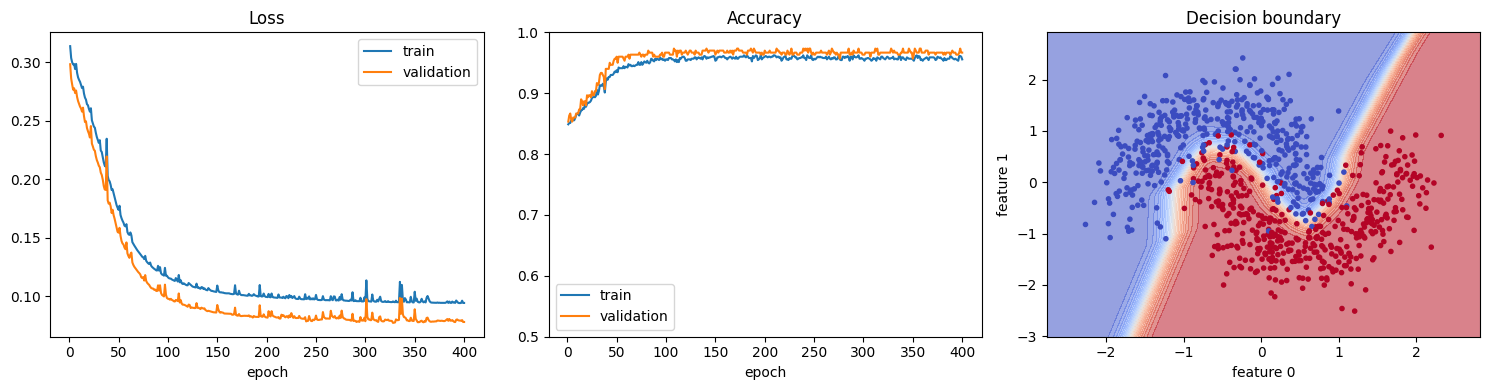

In [10]:
# 构造从 1 到训练轮数的横轴，和 history 中每条曲线等长。
epochs = np.arange(1, len(history["train_loss"]) + 1)
# 一行创建三个子图：loss、accuracy 和决策边界。
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘制训练集 loss，观察优化目标是否下降。
axes[0].plot(epochs, history["train_loss"], label="train")
# 绘制验证集 loss，观察是否与训练曲线持续分离。
axes[0].plot(epochs, history["val_loss"], label="validation")
# 设置第一个子图标题与横轴名称。
axes[0].set(title="Loss", xlabel="epoch")
# 显示 train/validation 图例。
axes[0].legend()

# 绘制训练集 accuracy。
axes[1].plot(epochs, history["train_acc"], label="train")
# 绘制验证集 accuracy。
axes[1].plot(epochs, history["val_acc"], label="validation")
# accuracy 的纵轴限制为 0.5 到 1.0，突出有效变化区间。
axes[1].set(title="Accuracy", xlabel="epoch", ylim=(0.5, 1.0))
# 显示第二个子图图例。
axes[1].legend()

# 在训练数据横轴范围两侧各增加 0.5，给决策边界留出边距。
x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
# 在训练数据纵轴范围两侧各增加 0.5。
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
# meshgrid 把两个一维坐标轴扩展为 220×220 的二维采样网格。
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
# ravel 展平两个网格后按列拼接，得到 (220*220, 2) 的模型输入。
grid = np.c_[xx.ravel(), yy.ravel()]
# 对所有网格点批量 forward，取类别 1 概率并恢复为二维网格。
class_one_probability = forward(grid, params).probs[:, 1].reshape(xx.shape)
# contourf 用连续颜色填充类别 1 概率，展示模型学到的非线性边界。
axes[2].contourf(xx, yy, class_one_probability, levels=25, cmap="coolwarm", alpha=0.55)
# 将训练样本覆盖到概率背景上，检查边界与真实标签的关系。
axes[2].scatter(x_train[:, 0], x_train[:, 1], c=y_train, s=9, cmap="coolwarm")
# 设置第三个子图的标题和坐标轴名称。
axes[2].set(title="Decision boundary", xlabel="feature 0", ylabel="feature 1")

# 自动调整三个子图间距，避免标题和坐标标签重叠。
plt.tight_layout()
# 显式显示组合图。
plt.show()


## 6. 学习率不是越大越快

保持数据、初始化和 batch 顺序不变，只修改学习率。较小学习率下降慢，合适学习率稳定收敛，过大学习率会在最优点两侧震荡甚至破坏训练。

lr=0.005 final_loss=0.2902 val_acc=0.867


lr=0.08  final_loss=0.1096 val_acc=0.970


lr=0.8   final_loss=0.0965 val_acc=0.973


lr=5.0   final_loss=0.2441 val_acc=0.830


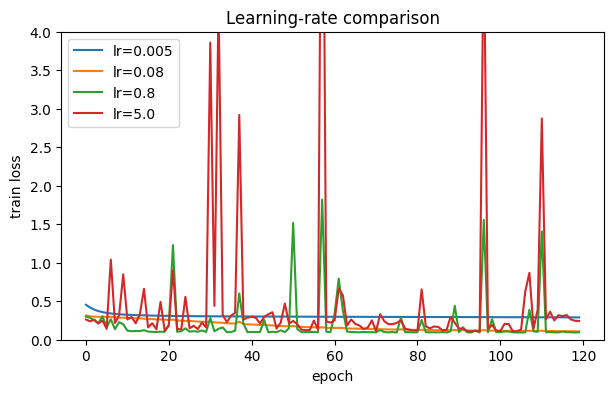

In [11]:
# 从过小、合适到过大选择四个学习率，覆盖不同训练行为。
learning_rates = [0.005, 0.08, 0.8, 5.0]
# 用字典按学习率保存完整历史，便于统一画图。
lr_histories = {}
# 每次实验只改变 learning_rate，其余数据、初始化和 batch 顺序保持一致。
for learning_rate in learning_rates:
    # 训练 120 轮用于快速对照；verbose=False 避免打印每个实验的中间日志。
    _, lr_history = train(
        x_train,
        y_train,
        x_val,
        y_val,
        epochs=120,
        learning_rate=learning_rate,
        verbose=False,
    )
    # 保存当前学习率的四条指标历史。
    lr_histories[learning_rate] = lr_history
    # 输出最终训练 loss 和验证 accuracy，形成紧凑实验摘要。
    print(
        f"lr={learning_rate:<5} final_loss={lr_history['train_loss'][-1]:.4f} "
        f"val_acc={lr_history['val_acc'][-1]:.3f}"
    )

# 创建学习率对照曲线画布。
plt.figure(figsize=(7, 4))
# 遍历所有实验，保证每个学习率都绘制在同一坐标系中。
for learning_rate, lr_history in lr_histories.items():
    # 绘制训练 loss，并在图例中标出学习率。
    plt.plot(lr_history["train_loss"], label=f"lr={learning_rate}")
# 限制纵轴上界，避免过大瞬时 loss 压扁主要曲线。
plt.ylim(0.0, 4.0)
# 横轴表示 epoch。
plt.xlabel("epoch")
# 纵轴表示训练集平均交叉熵。
plt.ylabel("train loss")
# 标题说明这是学习率对照实验。
plt.title("Learning-rate comparison")
# 显示每条曲线对应的学习率。
plt.legend()
# 显式显示对照图。
plt.show()


## 验收结论

- 数据准备、标准化、模型计算和训练均由 NumPy 完成，没有使用 autograd。
- 广播让一维 bias 自动作用到整个 batch；矩阵乘与转置决定参数梯度的 shape。
- 稳定 softmax 避免指数溢出；有限差分为手写 backward 提供可证伪的正确性检查。
- 训练集和验证集曲线同时记录，避免只凭最终 accuracy 判断训练是否健康。
- 下一阶段迁移到 PyTorch 时，Tensor、Module、autograd 和 optimizer 分别对应这里显式维护的数据、参数、反向传播和更新逻辑。